In [10]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

ds = xr.open_dataset('MODISLandUseData.nc')
print(ds)

<xarray.Dataset> Size: 54MB
Dimensions:              (time: 1, lat: 761, lon: 682)
Coordinates:
  * time                 (time) object 8B 2022-01-01 00:00:00
  * lat                  (lat) float64 6kB 39.72 39.72 39.71 ... 36.56 36.56
  * lon                  (lon) float64 5kB -77.56 -77.56 ... -74.73 -74.72
Data variables: (12/14)
    crs                  int8 1B ...
    LC_Prop1             (time, lat, lon) float64 4MB ...
    LC_Prop1_Assessment  (time, lat, lon) float64 4MB ...
    LC_Prop2             (time, lat, lon) float64 4MB ...
    LC_Prop2_Assessment  (time, lat, lon) float64 4MB ...
    LC_Prop3             (time, lat, lon) float64 4MB ...
    ...                   ...
    LC_Type2             (time, lat, lon) float64 4MB ...
    LC_Type3             (time, lat, lon) float64 4MB ...
    LC_Type4             (time, lat, lon) float64 4MB ...
    LC_Type5             (time, lat, lon) float64 4MB ...
    LW                   (time, lat, lon) float64 4MB ...
    QC             

In [11]:
# See what numeric classes are present in the primary type
unique_classes = np.unique(ds['LC_Type1'].values[~np.isnan(ds['LC_Type1'].values)])
print(f"Unique Land Cover Classes: {unique_classes}")

Unique Land Cover Classes: [ 1.  2.  3.  4.  5.  6.  8.  9. 10. 11. 12. 13. 14. 16. 17.]


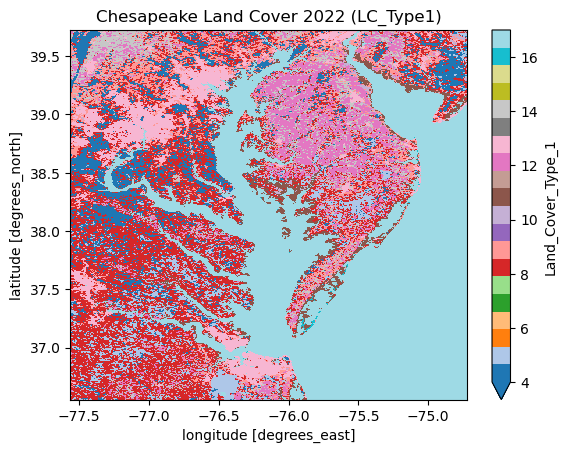

In [12]:
# Plot the primary land cover type
ds['LC_Type1'].squeeze().plot(cmap='tab20', robust=True)
plt.title("Chesapeake Land Cover 2022 (LC_Type1)")
plt.show()

In [13]:
# Convert the 2D grid to a flat list of values and count them
counts = ds['LC_Type1'].to_series().value_counts().sort_index()

# If you know class 17 is Water and 13 is Urban (standard IGBP):
print("Class ID | Pixel Count")
print(counts)


Class ID | Pixel Count
LC_Type1
1.0       2296
2.0         22
3.0         14
4.0      42697
5.0      26500
6.0          5
8.0     109337
9.0      34741
10.0      5821
11.0     16940
12.0     38127
13.0     32139
14.0     20983
16.0       383
17.0    188997
Name: count, dtype: int64


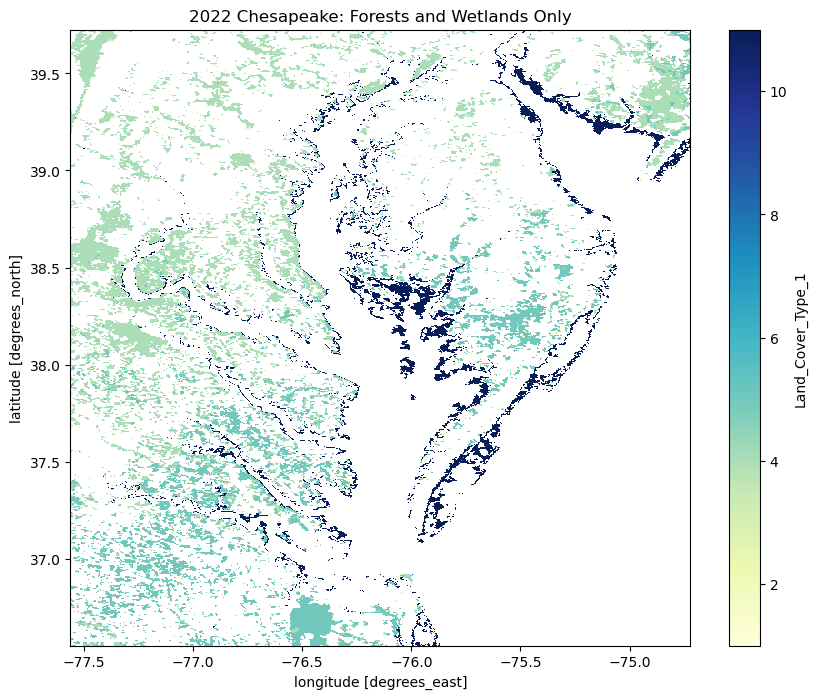

In [14]:

# 1. Create a mask: True if pixel is Forest (1-5) or Wetland (11)
target_mask = (ds['LC_Type1'] >= 1) & (ds['LC_Type1'] <= 5) | (ds['LC_Type1'] == 11)

# 2. Apply the mask to your data
# .where(condition) keeps data where True and sets the rest to NaN
forest_marsh_map = ds['LC_Type1'].where(target_mask)

# 3. Plot the result
plt.figure(figsize=(10, 8))
forest_marsh_map.squeeze().plot(cmap='YlGnBu') # Using a Green-Blue colormap for nature
plt.title("2022 Chesapeake: Forests and Wetlands Only")
plt.show()

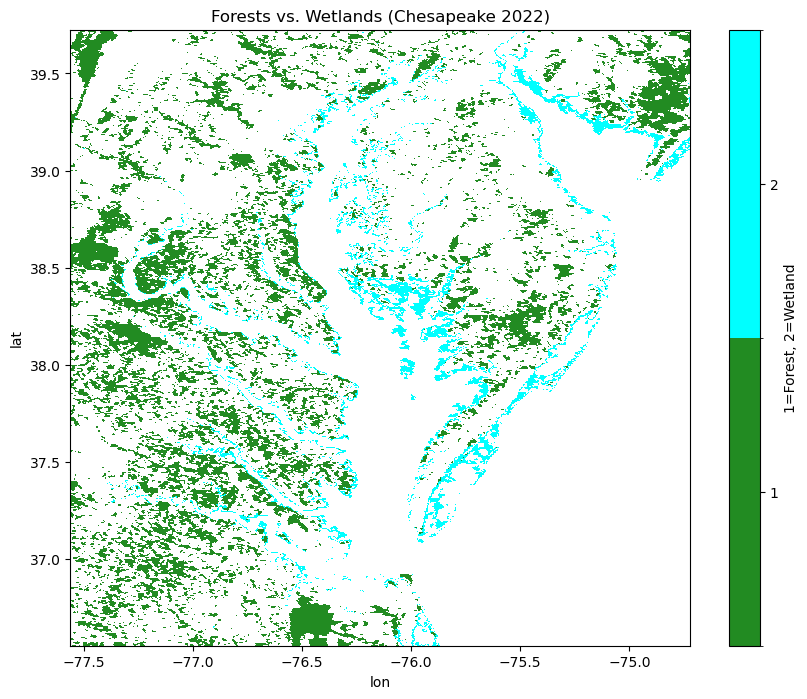

In [15]:

# 1. Create the simplified map
# Value 1 = Forest, Value 2 = Wetland
simplified = xr.where((ds['LC_Type1'] >= 1) & (ds['LC_Type1'] <= 5), 1, np.nan)
simplified = xr.where(ds['LC_Type1'] == 11, 2, simplified)

# 2. Plot with adjusted levels
plt.figure(figsize=(10, 8))
simplified.squeeze().plot(
    levels=[0.5, 1.5, 2.5], 
    colors=['#228B22', '#00FFFF'], # Forest Green for 1, Cyan for 2
    cbar_kwargs={'ticks': [1, 2], 'label': '1=Forest, 2=Wetland'}
)

plt.title("Forests vs. Wetlands (Chesapeake 2022)")
plt.show()


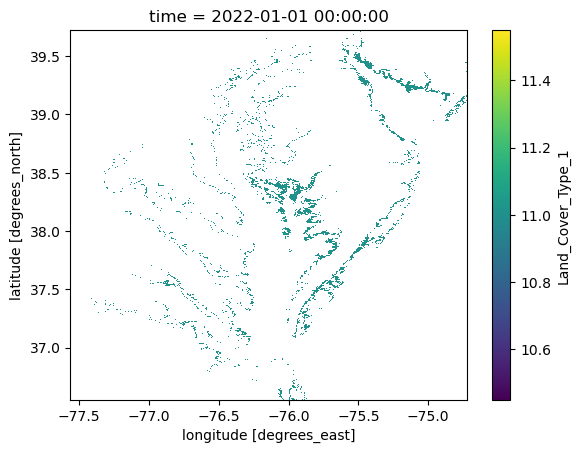

In [16]:
# Only show me wetlands where the confidence is higher than 80%
high_confidence_wetlands = ds['LC_Type1'].where((ds['LC_Type1'] == 11) & (ds['LC_Prop1_Assessment'] > 80))

high_confidence_wetlands.squeeze().plot()
